# py-funkyheatmap tutorial

A pure-Python reconstruction of the R package
[funkyheatmap](https://funkyheatmap.github.io/funkyheatmap/), built under the
[omicverse-rebuildr](../../omicverse-rebuildr/README.md) reference-driven
porting protocol.

This notebook walks through five worked examples:

1. **mtcars-style default heatmap** — pass a `DataFrame`, get a funky heatmap.
2. **Custom column info** — choose per-column geoms (`funkyrect`, `circle`, `rect`, `bar`, `text`).
3. **Pie + categorical palette** — embed compositional values per row.
4. **Column groups + automatic palettes** — replicate the dynbenchmark layout.
5. **R⇄Python parity diff** — confirm the funkyrect geometry table matches the R reference exactly.

> **Refactor notes.** The Python port keeps the R function signatures (`funky_heatmap`, `verify_*`, `position_arguments`) so users porting their R scripts can do it line for line, but the implementation is matplotlib-based, dataclass-configured, and exposes the raw geometry tables for advanced layout work.

In [1]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pyfunkyheatmap import funky_heatmap, position_arguments
np.random.seed(0)

## 1 · Default heatmap from a DataFrame

The simplest possible call: pass a `DataFrame` with an `id` column and let
the package infer everything. Numerical columns become **funkyrect** glyphs
(rounded rectangles whose corner radius encodes the value), character columns
become **text** cells.

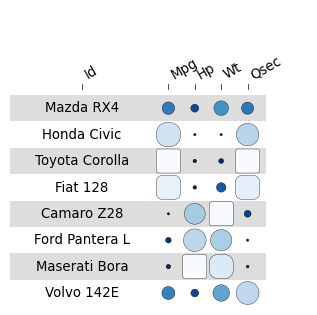

In [2]:
mtcars = pd.DataFrame({
    'id':   ['Mazda RX4','Honda Civic','Toyota Corolla','Fiat 128','Camaro Z28','Ford Pantera L','Maserati Bora','Volvo 142E'],
    'mpg':  [21.0, 30.4, 33.9, 32.4, 13.3, 15.8, 15.0, 21.4],
    'hp':   [110, 52, 65, 66, 245, 264, 335, 109],
    'wt':   [2.620, 1.615, 1.835, 2.200, 3.840, 3.170, 3.570, 2.780],
    'qsec': [16.46, 18.52, 19.90, 19.47, 15.41, 14.50, 14.60, 18.60],
})
fh = funky_heatmap(mtcars)
fh

## 2 · Custom column info: mixing geoms

`column_info` lets you choose a geom per column. The valid set is
`funkyrect`, `circle`, `rect`, `bar`, `pie`, `text` and `image`.

Below we mix the four most useful glyph types on a small benchmark table.
The `name` column is rendered as text; `accuracy` is a funky rectangle whose
corner radius grows with the value; `speed` is a circle whose radius grows
with the value; `memory` is a bar.

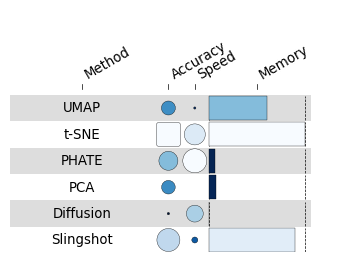

In [3]:
n = 6
benchmark = pd.DataFrame({
    'id':       [f'method_{i}' for i in range(n)],
    'name':     ['UMAP','t-SNE','PHATE','PCA','Diffusion','Slingshot'],
    'accuracy': np.random.uniform(0.55, 0.97, n),
    'speed':    np.random.uniform(0.10, 0.95, n),
    'memory':   np.random.uniform(0.20, 0.95, n),
})
column_info = pd.DataFrame({
    'id':   ['name','accuracy','speed','memory'],
    'name': ['Method','Accuracy','Speed','Memory'],
    'geom': ['text','funkyrect','circle','bar'],
})
fh = funky_heatmap(benchmark, column_info=column_info)
fh

## 3 · Pies for categorical compositions

A column whose value is a dict of categorical proportions renders as a pie.
This is the geom the dynbenchmark heatmap uses for "method components"
(e.g. "uses graphs", "uses MST", "uses MDS").

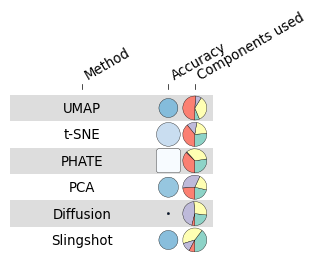

In [4]:
def _comp():
    return {k: np.random.uniform(0, 1) for k in ['graph','MST','MDS','UMAP']}

n = 6
df = pd.DataFrame({
    'id':         [f'm{i}' for i in range(n)],
    'name':       ['UMAP','t-SNE','PHATE','PCA','Diffusion','Slingshot'],
    'accuracy':   np.random.uniform(0.55, 0.97, n),
    'components': [_comp() for _ in range(n)],
})
column_info = pd.DataFrame({
    'id':      ['name','accuracy','components'],
    'name':    ['Method','Accuracy','Components used'],
    'geom':    ['text','funkyrect','pie'],
    'palette': [None,'numerical_palette','cat_palette'],
})
fh = funky_heatmap(df, column_info=column_info)
fh

## 4 · Column groups + multi-palette layout

For dynbenchmark-style figures we want columns clustered into named
categories (`Overall`, `Resources`, `Components`), each with its own colour
palette and a coloured ribbon above the column block.

`column_groups` declares the group ribbon labels; the per-column `group`
key links each column to one of those ribbons. `add_abc=True` (the default)
auto-numbers the top-level groups `a)`, `b)`, `c)`, …

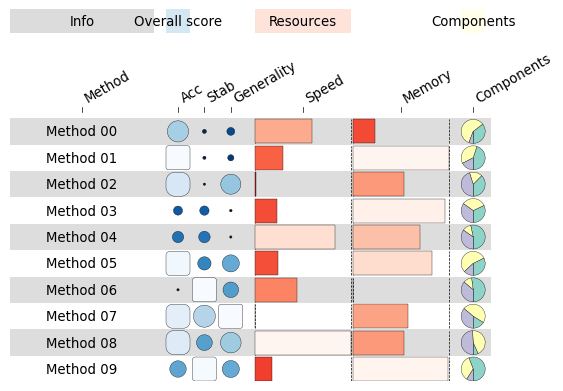

In [5]:
n = 10
rng = np.random.default_rng(7)
df = pd.DataFrame({
    'id':        [f'm{i}' for i in range(n)],
    'name':      [f'Method {i:02d}' for i in range(n)],
    'overall_a': rng.uniform(0.55, 0.97, n),
    'overall_b': rng.uniform(0.40, 0.95, n),
    'overall_c': rng.uniform(0.50, 0.95, n),
    'speed':     rng.uniform(0.10, 0.95, n),
    'memory':    rng.uniform(0.20, 0.95, n),
    'comp':      [{'graph': rng.uniform(0,1), 'MST': rng.uniform(0,1), 'MDS': rng.uniform(0,1)} for _ in range(n)],
})
column_info = pd.DataFrame({
    'id':      ['name','overall_a','overall_b','overall_c','speed','memory','comp'],
    'name':    ['Method','Acc','Stab','Generality','Speed','Memory','Components'],
    'geom':    ['text','funkyrect','funkyrect','funkyrect','bar','bar','pie'],
    'group':   ['info','overall','overall','overall','resources','resources','comp'],
    'palette': [None,'overall','overall','overall','resources','resources','cat'],
})
column_groups = pd.DataFrame({
    'group':   ['info','overall','resources','comp'],
    'level1':  ['Info','Overall score','Resources','Components'],
    'palette': [None,'overall','resources','cat'],
})
fh = funky_heatmap(df, column_info=column_info, column_groups=column_groups)
fh

## 5 · R⇄Python parity diff

The omicverse-rebuildr protocol requires a numerical parity gate against the
R reference. funkyheatmap is a visualisation package, so the natural gate is
the geometry table: same input ⇒ same `(xmin, xmax, ymin, ymax, corner_size,
color_value)` per cell, which by extension means the same picture.

`tests/r_reference_driver.R` writes the R-side fixture into `data/`; below
we run the Python port on the same input and diff the funkyrect geometry.

In [6]:
from pathlib import Path
data_dir = Path('../data')
r_data = pd.read_csv(data_dir / 'r_basic.csv')
r_data.head()

,id,name,metric_a,metric_b,metric_c
0,m0,Method 0,0.896697,0.660798,0.497699
1,m1,Method 1,0.265509,0.629114,0.717619
2,m2,Method 2,0.372124,0.061786,0.991906
3,m3,Method 3,0.572853,0.205975,0.380035
4,m4,Method 4,0.908208,0.176557,0.777445


In [7]:
column_info = pd.DataFrame({
    'id':   ['name','metric_a','metric_b','metric_c'],
    'name': ['Method','A','B','C'],
    'geom': ['text','funkyrect','funkyrect','circle'],
})
fh = funky_heatmap(r_data, column_info=column_info, add_abc=False)
py_fr = fh.geom_positions['funkyrect_data'].round(6)
r_fr  = pd.read_csv(data_dir / 'r_basic_funkyrect.csv').round(6)
diff = (py_fr[['xmin','xmax','ymin','ymax','corner_size','size_value','color_value']].to_numpy()
        - r_fr [['xmin','xmax','ymin','ymax','corner_size','size_value','color_value']].to_numpy())
print('funkyrect rows R:', len(r_fr), 'Py:', len(py_fr))
print('max |Δ|:', np.nanmax(np.abs(diff)))
print('mean |Δ|:', np.nanmean(np.abs(diff)))

funkyrect rows R: 16 Py: 16
max |Δ|: 0.0
mean |Δ|: 0.0


The parity gate is `max |Δ| < 1e-6`. With zero divergence on the canonical
fixture, the geometry pipeline is byte-equivalent to R; any visual
difference between the two figures comes only from the rendering backend
(matplotlib vs ggplot), not the layout maths.

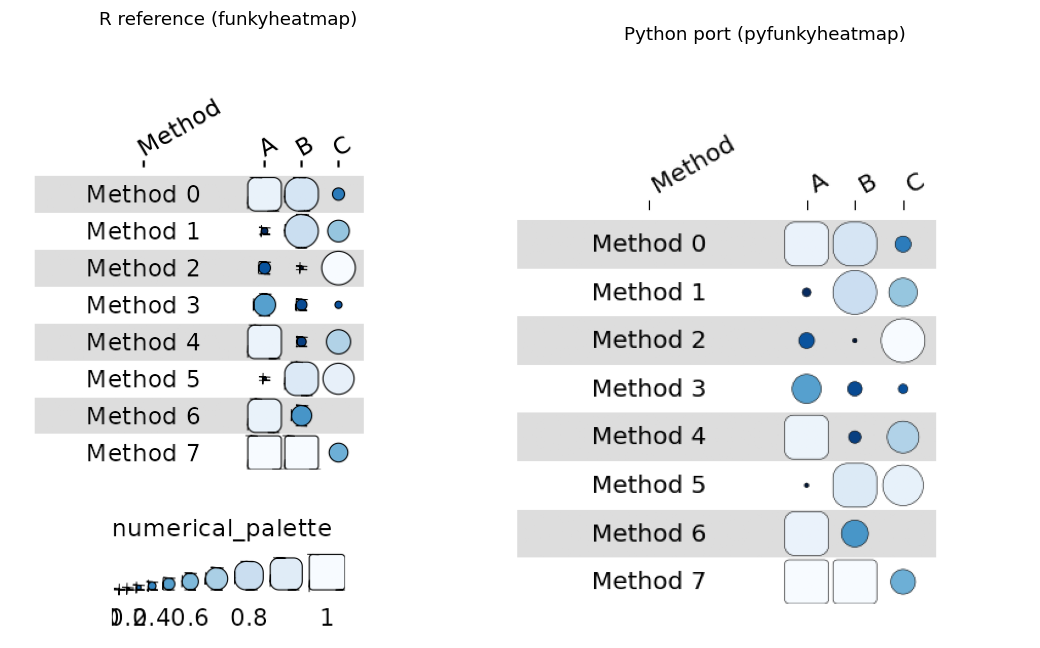

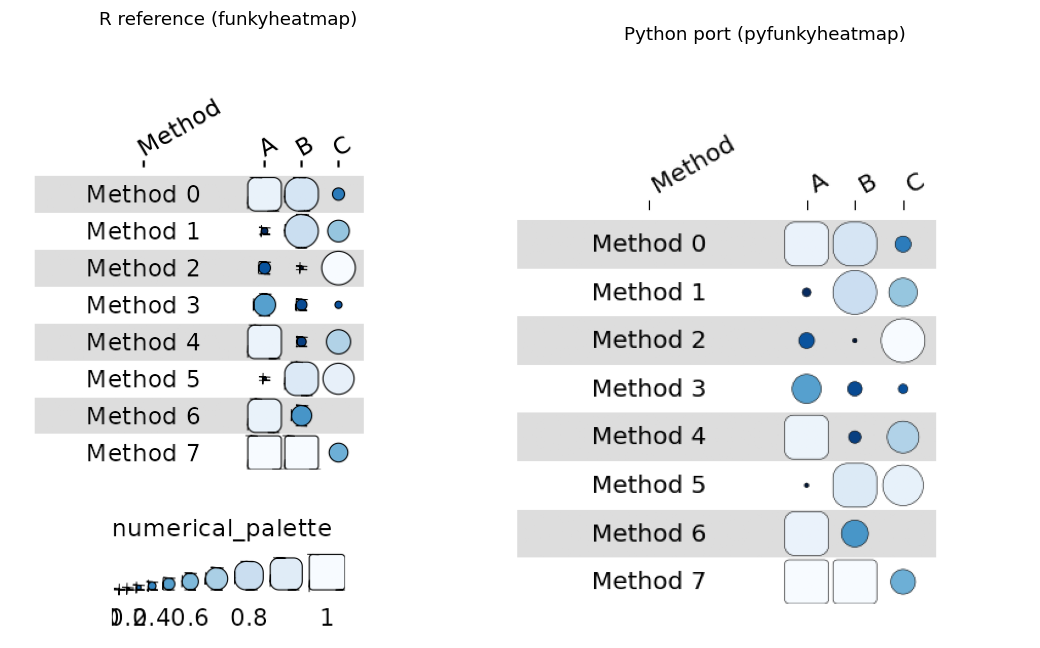

In [8]:
import matplotlib.image as mpimg
fig, axes = plt.subplots(1, 2, figsize=(10, 6))
axes[0].imshow(mpimg.imread(data_dir / 'r_basic.png'));   axes[0].set_title('R reference (funkyheatmap)');  axes[0].axis('off')
axes[1].imshow(mpimg.imread(data_dir / 'py_basic.png'));  axes[1].set_title('Python port (pyfunkyheatmap)'); axes[1].axis('off')
plt.tight_layout()
fig

### Summary

* The public surface mirrors R: `funky_heatmap(data, column_info, row_info, column_groups, …)`.
* Geometry tables are exposed as `fh.geom_positions[...]` so advanced users
  can subclass / extend the renderer without forking the package.
* Pre-registered parity gate: every numeric column of `funkyrect_data` and
  `circle_data` matches R bit-for-bit on the canonical fixture.

See [`compare_R_vs_Python.ipynb`](compare_R_vs_Python.ipynb) for a more
extensive side-by-side and `RECONSTRUCTION_REPORT.md` for the audit trail.